# Đánh giá Model DDPM1D_SelfConditional_maskedCond

Notebook này đánh giá hiệu quả của model **DDPM1D_SelfConditional_maskedCond** (Signal Conditional Model) theo các tasks trong paper BioDiffusion.

## Model Information
- **Model Type**: Self-Conditional Diffusion Model với Signal Conditioning
- **Dataset**: MIT-BIH Arrhythmia Database (Class 0 - Non-Ectopic Beats)
- **Sequence Length**: 128 timesteps
- **Objective**: v-parameterization

## Evaluation Tasks (theo paper Section D)
1. **Signal Denoising**: Loại bỏ noise từ signals bị nhiễu
2. **Signal Imputation**: Điền các giá trị bị thiếu trong signals
3. **Signal Super-resolution**: Tăng độ phân giải của signals
4. **Individual Signal Generation**: Generate nhiều signals từ một signal mẫu

## Evaluation Metrics
- **MSE (Mean Squared Error)**: Đánh giá độ chính xác reconstruction
- **MAE (Mean Absolute Error)**: Đánh giá độ lệch trung bình
- **Visual Comparison**: So sánh trực quan original vs restored signals


In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/biodiffusion"
os.chdir(base_path)

Mounted at /content/drive


In [2]:
# Import libraries
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils import data
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from MITBIH import mitbih_masked, mitbih_denosing, mitbih_imputation, reverse_cls_dit
from modules.modules1D_cond import Unet1D, GaussianDiffusion1D
from utils_cond import save_signals

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Configuration
CHECKPOINT_PATH = "checkpoint/DDPM1D_SelfConditional_maskedCond/checkpoint_best.pt"
TEST_DATA_PATH = "datasets/heartbeat/mitbih_test.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model hyperparameters
SEQ_LENGTH = 128
DIM = 64
DIM_MULTS = (1, 2, 4, 8)
CHANNELS = 1
SELF_CONDITION = True
OBJECTIVE = 'pred_v'
CLASS_ID = 0  # Class 0: Non-Ectopic Beats

# Evaluation parameters
N_SAMPLES = 50  # Số lượng samples để đánh giá

print(f"Device: {DEVICE}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Test data path: {TEST_DATA_PATH}")
print(f"Class ID: {CLASS_ID} ({reverse_cls_dit[CLASS_ID]})")


Device: cuda
Checkpoint path: checkpoint/DDPM1D_SelfConditional_maskedCond/checkpoint_best.pt
Test data path: datasets/heartbeat/mitbih_test.csv
Class ID: 0 (Non-Ectopic Beats)


## 1. Load Model từ Checkpoint


In [4]:
def load_model(checkpoint_path, seq_length=128, device='cuda',
               dim=64, dim_mults=(1, 2, 4, 8), channels=1,
               self_condition=True, objective='pred_v'):
    """Load trained signal conditional model from checkpoint"""
    model = Unet1D(
        dim=dim,
        dim_mults=dim_mults,
        channels=channels,
        self_condition=self_condition
    ).to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    elif 'model' in checkpoint:
        if hasattr(checkpoint['model'], 'state_dict'):
            state_dict = checkpoint['model'].state_dict()
        else:
            state_dict = checkpoint['model']
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict, strict=False)
    model.eval()

    diffusion = GaussianDiffusion1D(
        model,
        seq_length=seq_length,
        timesteps=1000,
        objective=objective
    ).to(device)
    diffusion.eval()

    return model, diffusion

# Load model
print("Loading model...")
model, diffusion = load_model(
    CHECKPOINT_PATH, SEQ_LENGTH, DEVICE,
    DIM, DIM_MULTS, CHANNELS, SELF_CONDITION, OBJECTIVE
)
print("Model loaded successfully!")


Loading model...
Model loaded successfully!


## 2. Task 1: Signal Denoising


Loading denoising test dataset...
Data shape of Non-Ectopic Beats instances = (18118, 1, 128)
Denoising dataset loaded: 18118 samples
Processing denoising samples...


Denoising:   0%|          | 0/1133 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising:   0%|          | 1/1133 [00:30<9:33:51, 30.42s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising:   0%|          | 3/1133 [01:29<9:22:17, 29.86s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising:   0%|          | 4/1133 [01:59<9:21:29, 29.84s/it]


Processed 50 samples

Denoising Metrics:
  MSE: 0.111974
  MAE: 0.240747


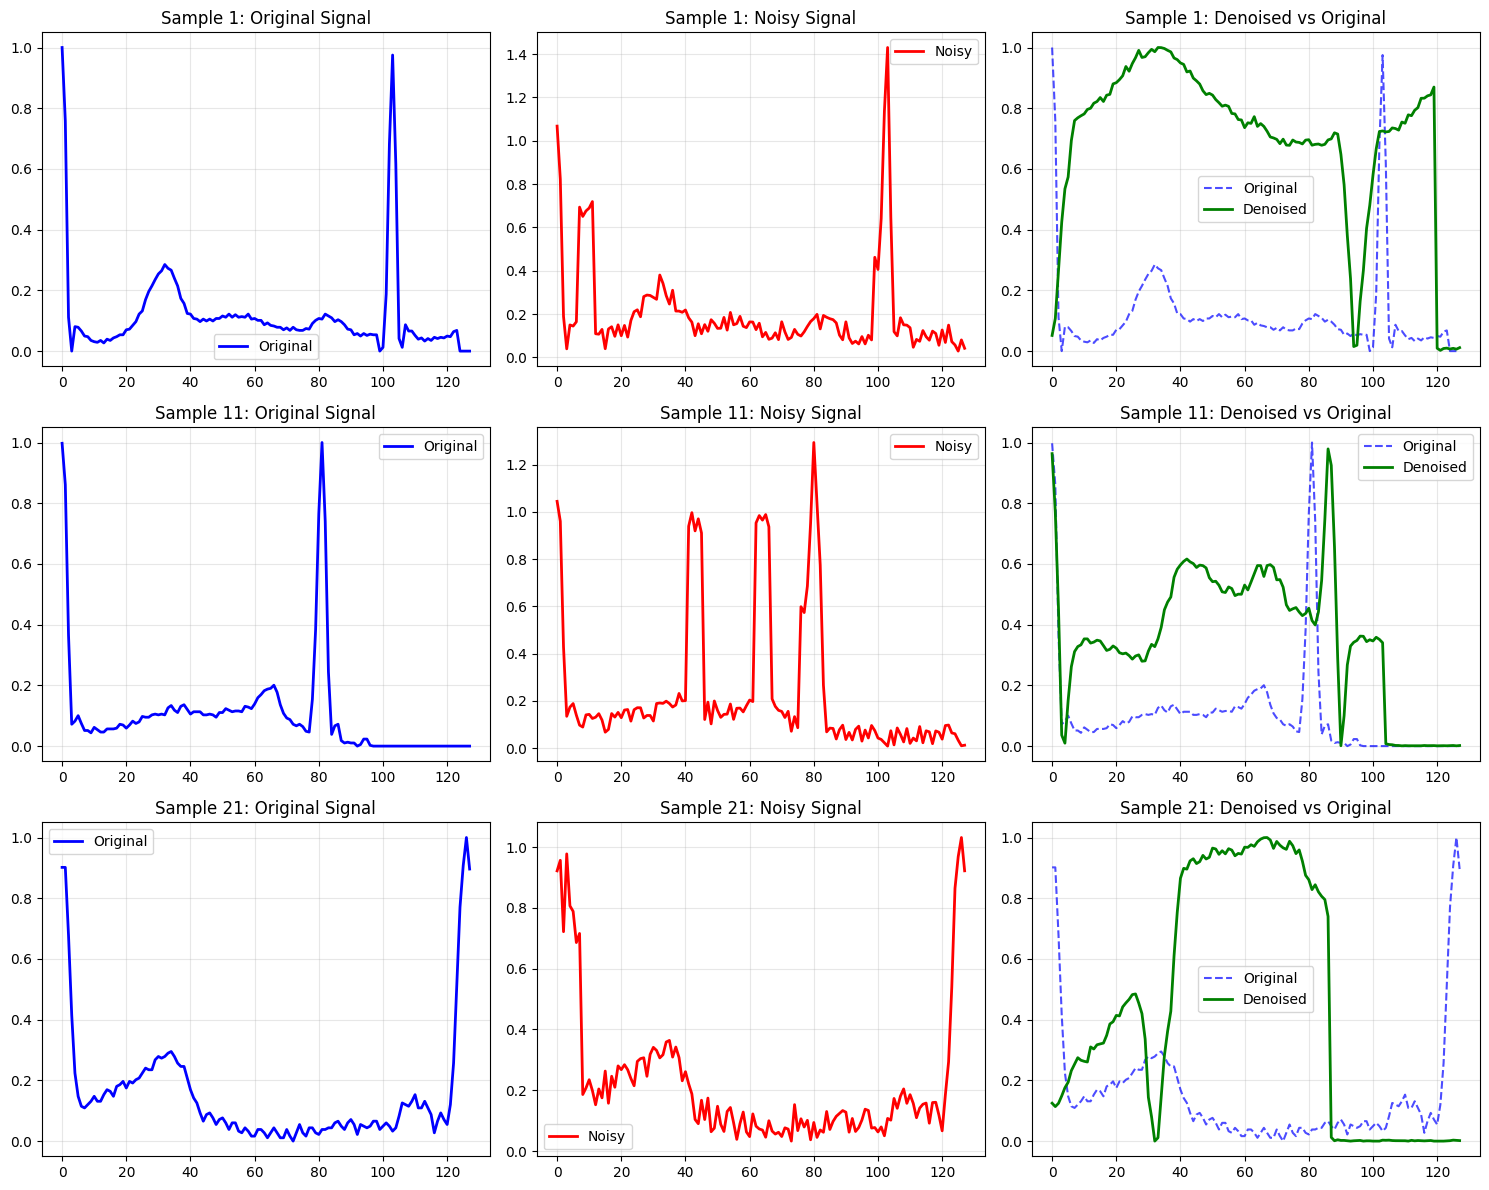

In [6]:
# Load denoising test dataset
print("Loading denoising test dataset...")
denoising_dataset = mitbih_denosing(dataroot='datasets/heartbeat', train_mode=False, class_id=CLASS_ID)
denoising_dataloader = data.DataLoader(denoising_dataset, batch_size=16, shuffle=False, num_workers=0)
print(f"Denoising dataset loaded: {len(denoising_dataset)} samples")

# Collect samples for evaluation
original_signals = []
noisy_signals = []
denoised_signals = []

print("Processing denoising samples...")
for i, data_dict in enumerate(tqdm(denoising_dataloader, desc="Denoising")):
    if i * 16 >= N_SAMPLES:
        break

    org_signal = data_dict['ORG'].to(DEVICE).float()  # Original clean signal
    cond_signal = data_dict['COND'].to(DEVICE).float()  # Noisy signal

    # Normalize conditional signal
    cond_signal_norm = diffusion.normalize(cond_signal)

    # Generate denoised signal
    with torch.no_grad():
        denoised = diffusion.sample(input_cond=cond_signal_norm, batch_size=cond_signal.shape[0])

    original_signals.append(org_signal.cpu().numpy())
    noisy_signals.append(cond_signal.cpu().numpy())
    denoised_signals.append(denoised.cpu().numpy())

original_signals = np.concatenate(original_signals, axis=0)[:N_SAMPLES]
noisy_signals = np.concatenate(noisy_signals, axis=0)[:N_SAMPLES]
denoised_signals = np.concatenate(denoised_signals, axis=0)[:N_SAMPLES]

print(f"Processed {len(original_signals)} samples")

# Calculate metrics
mse_denoising = np.mean((original_signals - denoised_signals) ** 2)
mae_denoising = np.mean(np.abs(original_signals - denoised_signals))

print(f"\nDenoising Metrics:")
print(f"  MSE: {mse_denoising:.6f}")
print(f"  MAE: {mae_denoising:.6f}")

# Visualize results
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i in range(3):
    idx = i * 10
    if idx < len(original_signals):
        sig_org = original_signals[idx, 0, :]
        sig_noisy = noisy_signals[idx, 0, :]
        sig_denoised = denoised_signals[idx, 0, :]

        axes[i, 0].plot(sig_org, 'b-', linewidth=2, label='Original')
        axes[i, 0].set_title(f'Sample {idx+1}: Original Signal')
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()

        axes[i, 1].plot(sig_noisy, 'r-', linewidth=2, label='Noisy')
        axes[i, 1].set_title(f'Sample {idx+1}: Noisy Signal')
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

        axes[i, 2].plot(sig_org, 'b--', linewidth=1.5, alpha=0.7, label='Original')
        axes[i, 2].plot(sig_denoised, 'g-', linewidth=2, label='Denoised')
        axes[i, 2].set_title(f'Sample {idx+1}: Denoised vs Original')
        axes[i, 2].grid(True, alpha=0.3)
        axes[i, 2].legend()

plt.tight_layout()
os.makedirs("results/DDPM1D_SelfConditional_maskedCond", exist_ok=True)
plt.savefig("results/DDPM1D_SelfConditional_maskedCond/denoising_results.png", dpi=150, bbox_inches='tight')
plt.show()


## 3. Task 2: Signal Imputation


Loading imputation test dataset...
Imputation dataset loaded: 18118 samples
Processing imputation samples...


Imputation:   0%|          | 0/1133 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Imputation:   0%|          | 1/1133 [00:30<9:41:52, 30.84s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Imputation:   0%|          | 3/1133 [01:30<9:23:03, 29.90s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Imputation:   0%|          | 4/1133 [02:00<9:28:50, 30.23s/it]


Processed 50 samples

Imputation Metrics:
  MSE: 0.096294
  MAE: 0.215713


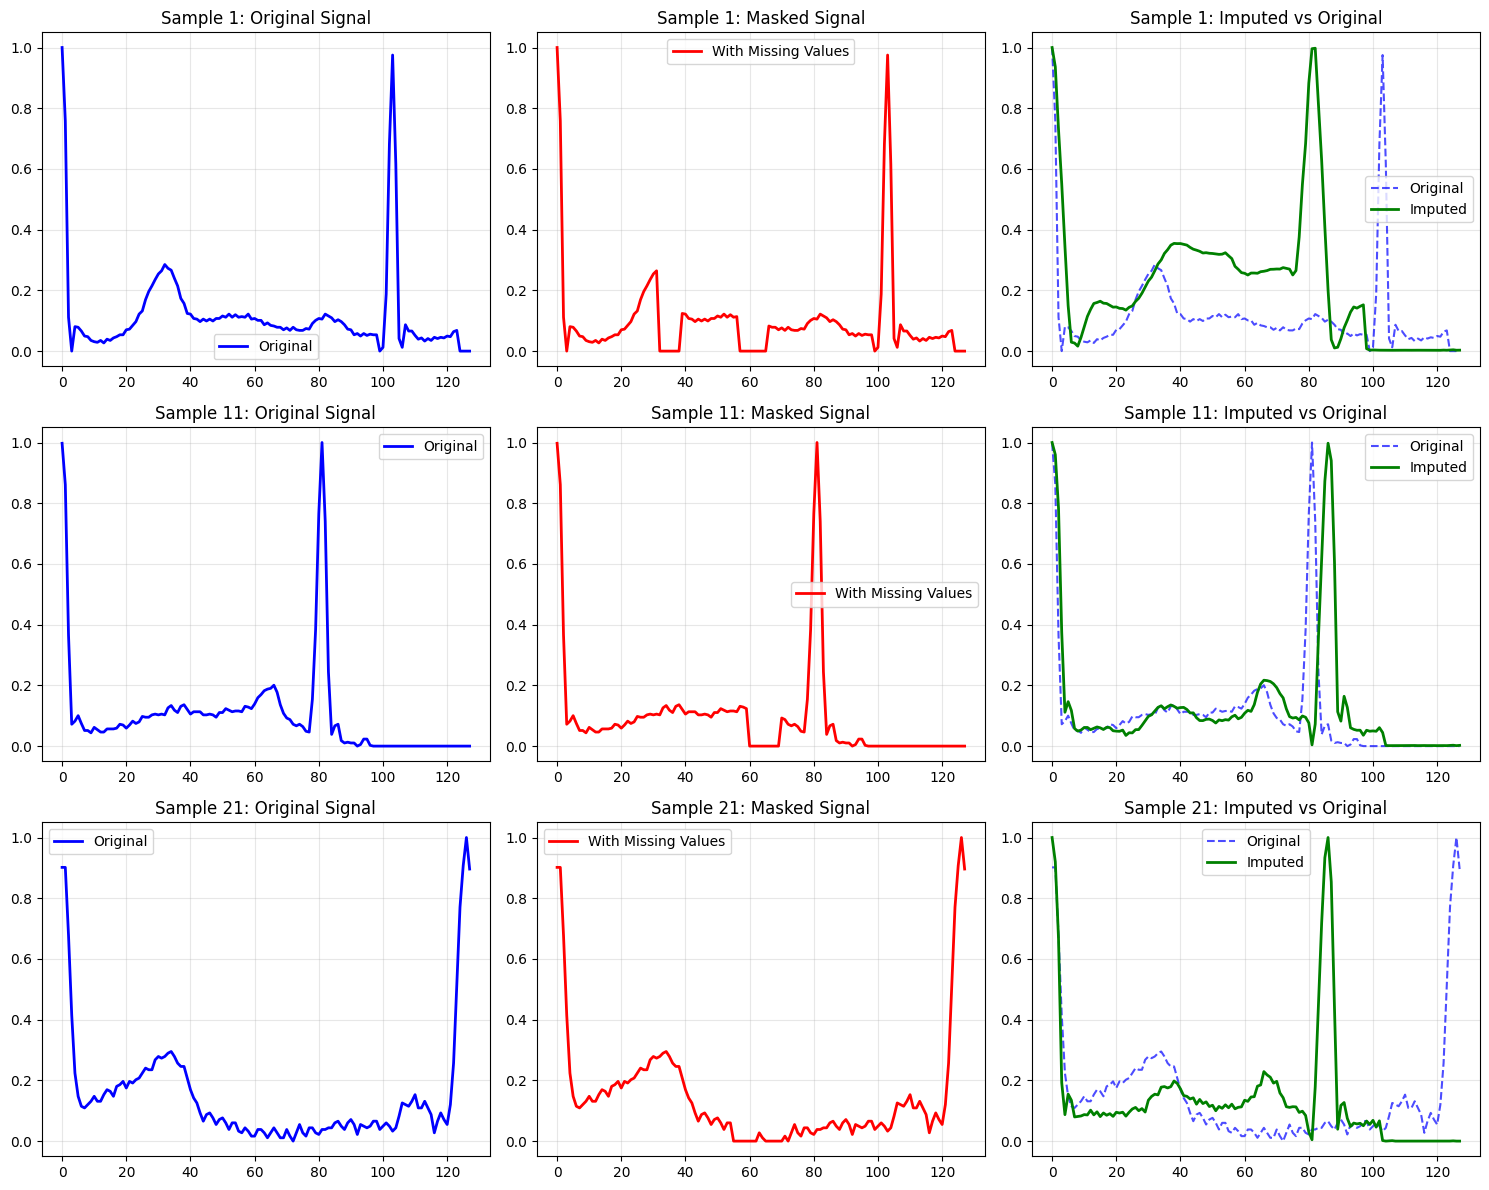

In [8]:
# Load imputation test dataset
print("Loading imputation test dataset...")
imputation_dataset = mitbih_imputation(dataroot='datasets/heartbeat', train_mode=False, class_id=CLASS_ID)
imputation_dataloader = data.DataLoader(imputation_dataset, batch_size=16, shuffle=False, num_workers=0)
print(f"Imputation dataset loaded: {len(imputation_dataset)} samples")

# Collect samples for evaluation
original_impute = []
masked_impute = []
imputed_signals = []

print("Processing imputation samples...")
for i, data_dict in enumerate(tqdm(imputation_dataloader, desc="Imputation")):
    if i * 16 >= N_SAMPLES:
        break

    # Convert to float32 tensors and move to device
    org_signal = torch.tensor(data_dict['ORG'], dtype=torch.float32).to(DEVICE)  # Original signal
    cond_signal = torch.tensor(data_dict['COND'], dtype=torch.float32).to(DEVICE)  # Signal with missing values

    # Normalize conditional signal
    cond_signal_norm = diffusion.normalize(cond_signal)

    # Generate imputed signal
    with torch.no_grad():
        imputed = diffusion.sample(input_cond=cond_signal_norm, batch_size=cond_signal.shape[0])

    original_impute.append(org_signal.cpu().numpy())
    masked_impute.append(cond_signal.cpu().numpy())
    imputed_signals.append(imputed.cpu().numpy())

original_impute = np.concatenate(original_impute, axis=0)[:N_SAMPLES]
masked_impute = np.concatenate(masked_impute, axis=0)[:N_SAMPLES]
imputed_signals = np.concatenate(imputed_signals, axis=0)[:N_SAMPLES]

print(f"Processed {len(original_impute)} samples")

# Calculate metrics
mse_imputation = np.mean((original_impute - imputed_signals) ** 2)
mae_imputation = np.mean(np.abs(original_impute - imputed_signals))

print(f"\nImputation Metrics:")
print(f"  MSE: {mse_imputation:.6f}")
print(f"  MAE: {mae_imputation:.6f}")

# Visualize results
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i in range(3):
    idx = i * 10
    if idx < len(original_impute):
        sig_org = original_impute[idx, 0, :]
        sig_masked = masked_impute[idx, 0, :]
        sig_imputed = imputed_signals[idx, 0, :]

        axes[i, 0].plot(sig_org, 'b-', linewidth=2, label='Original')
        axes[i, 0].set_title(f'Sample {idx+1}: Original Signal')
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()

        axes[i, 1].plot(sig_masked, 'r-', linewidth=2, label='With Missing Values')
        axes[i, 1].set_title(f'Sample {idx+1}: Masked Signal')
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

        axes[i, 2].plot(sig_org, 'b--', linewidth=1.5, alpha=0.7, label='Original')
        axes[i, 2].plot(sig_imputed, 'g-', linewidth=2, label='Imputed')
        axes[i, 2].set_title(f'Sample {idx+1}: Imputed vs Original')
        axes[i, 2].grid(True, alpha=0.3)
        axes[i, 2].legend()

plt.tight_layout()
plt.savefig("results/DDPM1D_SelfConditional_maskedCond/imputation_results.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. Task 3: Signal Super-resolution


Loading test dataset for super-resolution...
Data shape of Non-Ectopic Beats instances = (18118, 1, 128)
Test dataset loaded: 18118 samples
Processing super-resolution samples...


Super-resolution:   0%|          | 0/1133 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Super-resolution:   0%|          | 1/1133 [00:29<9:23:32, 29.87s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Super-resolution:   0%|          | 3/1133 [01:30<9:28:43, 30.20s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Super-resolution:   0%|          | 4/1133 [02:00<9:25:48, 30.07s/it]


Processed 50 samples

Super-resolution Metrics:
  MSE: 0.090150
  MAE: 0.212033


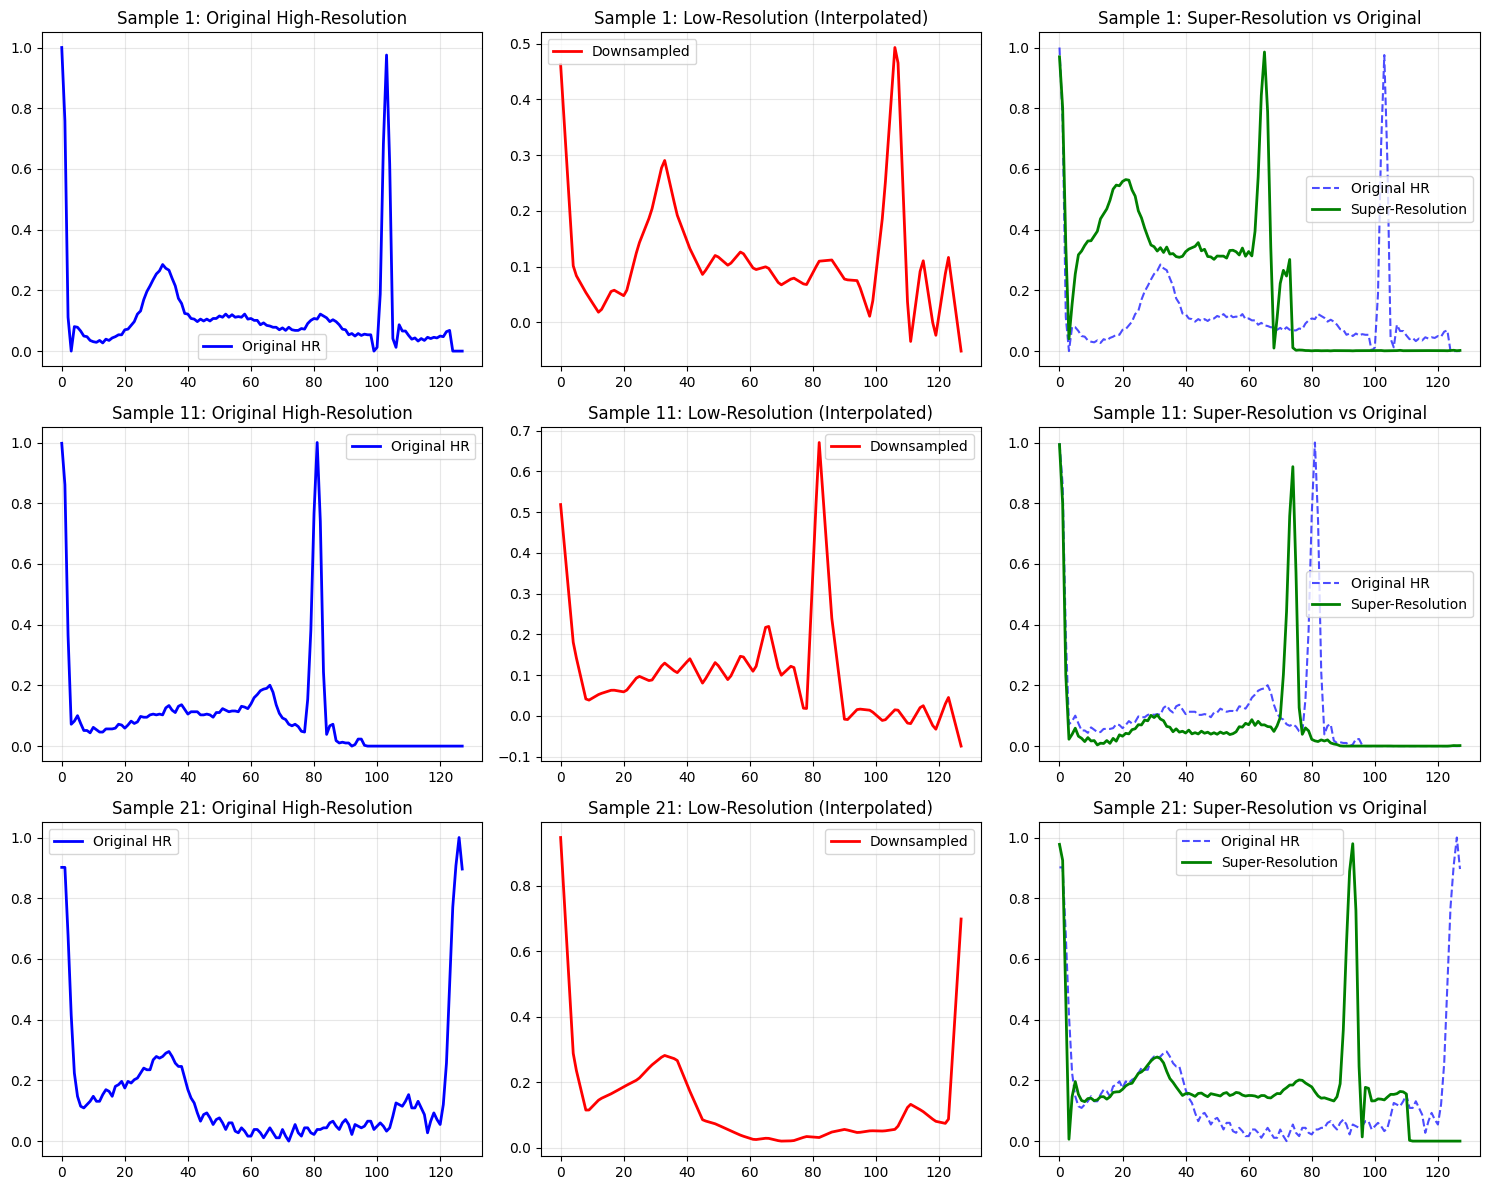

In [10]:
# Load test dataset for super-resolution
print("Loading test dataset for super-resolution...")
test_dataset = mitbih_masked(filename=TEST_DATA_PATH, class_id=CLASS_ID)
test_dataloader = data.DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
print(f"Test dataset loaded: {len(test_dataset)} samples")

# Create downsampled signals (simulate low resolution)
from scipy import signal as scipy_signal

original_sr = []
downsampled_sr = []
superres_signals = []

print("Processing super-resolution samples...")
for i, data_dict in enumerate(tqdm(test_dataloader, desc="Super-resolution")):
    if i * 16 >= N_SAMPLES:
        break

    org_signal = data_dict['org_data'].to(DEVICE)  # Original high-res signal

    # Downsample by factor of 4
    org_np = org_signal.cpu().numpy()
    downsampled_np = np.zeros_like(org_np)

    for j in range(org_np.shape[0]):
        for ch in range(org_np.shape[1]):
            sig = org_np[j, ch, :]
            # Downsample
            downsampled = scipy_signal.resample(sig, len(sig) // 4)
            # Upsample back using linear interpolation (low quality)
            downsampled_np[j, ch, :] = np.interp(
                np.linspace(0, len(downsampled)-1, len(sig)),
                np.arange(len(downsampled)),
                downsampled
            )

    downsampled_signal = torch.from_numpy(downsampled_np).float().to(DEVICE)

    # Normalize downsampled signal
    downsampled_norm = diffusion.normalize(downsampled_signal)

    # Generate super-resolution signal
    with torch.no_grad():
        superres = diffusion.sample(input_cond=downsampled_norm, batch_size=downsampled_signal.shape[0])

    original_sr.append(org_signal.cpu().numpy())
    downsampled_sr.append(downsampled_signal.cpu().numpy())
    superres_signals.append(superres.cpu().numpy())

original_sr = np.concatenate(original_sr, axis=0)[:N_SAMPLES]
downsampled_sr = np.concatenate(downsampled_sr, axis=0)[:N_SAMPLES]
superres_signals = np.concatenate(superres_signals, axis=0)[:N_SAMPLES]

print(f"Processed {len(original_sr)} samples")

# Calculate metrics
mse_superres = np.mean((original_sr - superres_signals) ** 2)
mae_superres = np.mean(np.abs(original_sr - superres_signals))

print(f"\nSuper-resolution Metrics:")
print(f"  MSE: {mse_superres:.6f}")
print(f"  MAE: {mae_superres:.6f}")

# Visualize results
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i in range(3):
    idx = i * 10
    if idx < len(original_sr):
        sig_org = original_sr[idx, 0, :]
        sig_downsampled = downsampled_sr[idx, 0, :]
        sig_superres = superres_signals[idx, 0, :]

        axes[i, 0].plot(sig_org, 'b-', linewidth=2, label='Original HR')
        axes[i, 0].set_title(f'Sample {idx+1}: Original High-Resolution')
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()

        axes[i, 1].plot(sig_downsampled, 'r-', linewidth=2, label='Downsampled')
        axes[i, 1].set_title(f'Sample {idx+1}: Low-Resolution (Interpolated)')
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

        axes[i, 2].plot(sig_org, 'b--', linewidth=1.5, alpha=0.7, label='Original HR')
        axes[i, 2].plot(sig_superres, 'g-', linewidth=2, label='Super-Resolution')
        axes[i, 2].set_title(f'Sample {idx+1}: Super-Resolution vs Original')
        axes[i, 2].grid(True, alpha=0.3)
        axes[i, 2].legend()

plt.tight_layout()
plt.savefig("results/DDPM1D_SelfConditional_maskedCond/superresolution_results.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Task 4: Individual Signal Generation


Loading sample signal for individual generation...
Data shape of Non-Ectopic Beats instances = (18118, 1, 128)
Generating 10 signals from single sample...


Generating:   0%|          | 0/10 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating:  10%|█         | 1/10 [00:30<04:30, 30.02s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating:  90%|█████████ | 9/10 [04:18<00:28, 28.61s/it]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating: 100%|██████████| 10/10 [04:47<00:00, 28.76s/it]


Generated 10 signals


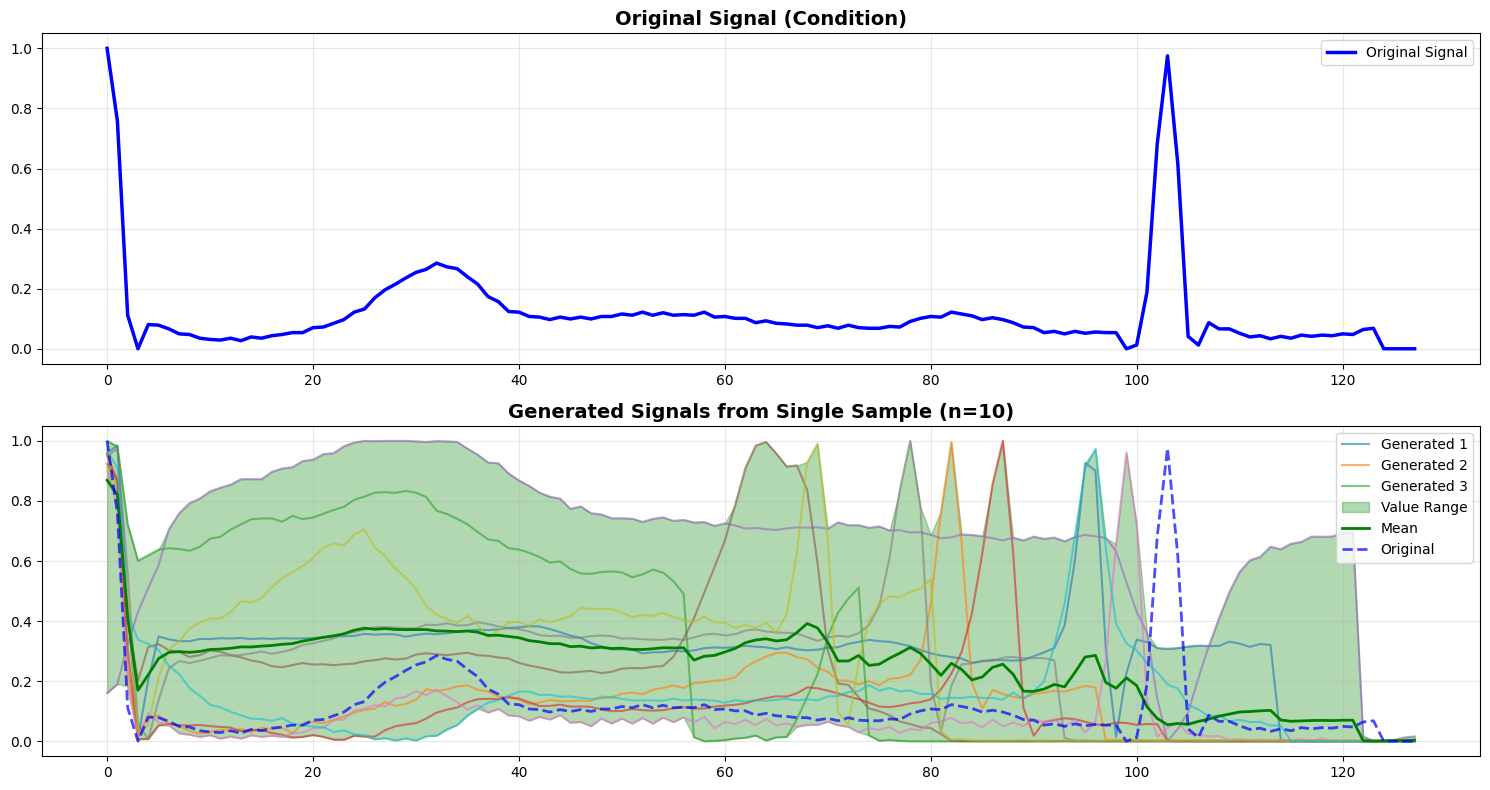

In [9]:
# Load a single signal as condition
print("Loading sample signal for individual generation...")
sample_dataset = mitbih_masked(filename=TEST_DATA_PATH, class_id=CLASS_ID)
sample_signal = sample_dataset[0]['org_data']  # Get first signal
sample_signal = torch.from_numpy(sample_signal).float().unsqueeze(0).to(DEVICE)

# Normalize
sample_signal_norm = diffusion.normalize(sample_signal)

# Generate multiple signals from this single signal
N_GENERATED = 10
print(f"Generating {N_GENERATED} signals from single sample...")

generated_from_one = []
with torch.no_grad():
    for _ in tqdm(range(N_GENERATED), desc="Generating"):
        generated = diffusion.sample(input_cond=sample_signal_norm, batch_size=1)
        generated_from_one.append(generated.cpu().numpy())

generated_from_one = np.concatenate(generated_from_one, axis=0)

print(f"Generated {len(generated_from_one)} signals")

# Visualize results
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plot all generated signals
sample_sig = sample_signal.cpu().numpy()[0, 0, :]
axes[0].plot(sample_sig, 'b-', linewidth=2.5, label='Original Signal')
axes[0].set_title('Original Signal (Condition)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot generated signals with range
for i, gen_sig in enumerate(generated_from_one):
    axes[1].plot(gen_sig[0, :], alpha=0.6, linewidth=1.5, label=f'Generated {i+1}' if i < 3 else '')

# Calculate and plot range
gen_mean = np.mean(generated_from_one[:, 0, :], axis=0)
gen_std = np.std(generated_from_one[:, 0, :], axis=0)
gen_min = np.min(generated_from_one[:, 0, :], axis=0)
gen_max = np.max(generated_from_one[:, 0, :], axis=0)

axes[1].fill_between(range(len(gen_mean)), gen_min, gen_max, alpha=0.3, color='green', label='Value Range')
axes[1].plot(gen_mean, 'g-', linewidth=2, label='Mean')
axes[1].plot(sample_sig, 'b--', linewidth=2, alpha=0.7, label='Original')
axes[1].set_title(f'Generated Signals from Single Sample (n={N_GENERATED})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("results/DDPM1D_SelfConditional_maskedCond/individual_generation.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary và Lưu Kết Quả


In [11]:
# Create results directory
results_dir = Path("results/DDPM1D_SelfConditional_maskedCond")
results_dir.mkdir(parents=True, exist_ok=True)

# Save results
results = {
    'denoising': {
        'mse': float(mse_denoising),
        'mae': float(mae_denoising),
        'n_samples': len(original_signals)
    },
    'imputation': {
        'mse': float(mse_imputation),
        'mae': float(mae_imputation),
        'n_samples': len(original_impute)
    },
    'super_resolution': {
        'mse': float(mse_superres),
        'mae': float(mae_superres),
        'n_samples': len(original_sr)
    },
    'individual_generation': {
        'n_generated': N_GENERATED
    }
}

# Save to text file
results_path = results_dir / "evaluation_results.txt"
with open(results_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("Model Evaluation Results - DDPM1D_SelfConditional_maskedCond\n")
    f.write("="*60 + "\n\n")
    f.write(f"Checkpoint: {CHECKPOINT_PATH}\n")
    f.write(f"Test Dataset: {TEST_DATA_PATH}\n")
    f.write(f"Class ID: {CLASS_ID} ({reverse_cls_dit[CLASS_ID]})\n\n")

    f.write("="*60 + "\n")
    f.write("Task 1: Signal Denoising\n")
    f.write("="*60 + "\n")
    f.write(f"Number of samples: {results['denoising']['n_samples']}\n")
    f.write(f"MSE: {results['denoising']['mse']:.6f}\n")
    f.write(f"MAE: {results['denoising']['mae']:.6f}\n\n")

    f.write("="*60 + "\n")
    f.write("Task 2: Signal Imputation\n")
    f.write("="*60 + "\n")
    f.write(f"Number of samples: {results['imputation']['n_samples']}\n")
    f.write(f"MSE: {results['imputation']['mse']:.6f}\n")
    f.write(f"MAE: {results['imputation']['mae']:.6f}\n\n")

    f.write("="*60 + "\n")
    f.write("Task 3: Signal Super-resolution\n")
    f.write("="*60 + "\n")
    f.write(f"Number of samples: {results['super_resolution']['n_samples']}\n")
    f.write(f"MSE: {results['super_resolution']['mse']:.6f}\n")
    f.write(f"MAE: {results['super_resolution']['mae']:.6f}\n\n")

    f.write("="*60 + "\n")
    f.write("Task 4: Individual Signal Generation\n")
    f.write("="*60 + "\n")
    f.write(f"Number of generated signals: {results['individual_generation']['n_generated']}\n")

print(f"\nResults saved to: {results_path}")

# Print summary
print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print("\n1. Signal Denoising:")
print(f"   MSE: {mse_denoising:.6f}")
print(f"   MAE: {mae_denoising:.6f}")

print("\n2. Signal Imputation:")
print(f"   MSE: {mse_imputation:.6f}")
print(f"   MAE: {mae_imputation:.6f}")

print("\n3. Signal Super-resolution:")
print(f"   MSE: {mse_superres:.6f}")
print(f"   MAE: {mae_superres:.6f}")

print("\n4. Individual Signal Generation:")
print(f"   Generated {N_GENERATED} signals from single sample")
print("="*60)



Results saved to: results/DDPM1D_SelfConditional_maskedCond/evaluation_results.txt

EVALUATION SUMMARY

1. Signal Denoising:
   MSE: 0.111974
   MAE: 0.240747

2. Signal Imputation:
   MSE: 0.096294
   MAE: 0.215713

3. Signal Super-resolution:
   MSE: 0.090150
   MAE: 0.212033

4. Individual Signal Generation:
   Generated 10 signals from single sample
